# Etapa 7 — Avaliação Cruzada · Stage 6 (FinBERT, 17 anos)

Este notebook reavalia os 4 modelos do projeto (BiLSTM original, BiLSTM reduzido, XGBoost, Transformer) sobre o dataset **Histórico estendido (~2009–2026) com sentimento FinBERT-PT-BR**, usando os utilitários compartilhados em `shared/` para garantir comparabilidade entre etapas.

## Protocolo

- Split walk-forward 70/15/15 (sem leakage temporal).
- Mesma normalização e mesmo target binário (sobe/desce).
- Métricas reportadas: **ROC-AUC** (primária), F1 por classe, accuracy, matriz de confusão.
- Resultados salvos em `results/` para consolidação cross-stage.

## Hipótese desta configuração

Mais regimes de mercado (crise 2008, COVID, ciclo Selic) tornam o modelo mais robusto. *Risco: não-estacionariedade pode degradar a performance se a relação sentimento↔preço variar entre regimes.*

Ver `README.md` desta pasta e `BALANCEAMENTO_DE_CLASSES.md` para discussão de métricas em datasets desbalanceados.

In [1]:
import sys
import os
import logging

sys.path.insert(0, '.')

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")

from shared.data_loader import load_stage6_finbert_17y
from shared.trainer import train_and_evaluate, save_results_json
from shared.plots import (
    plot_roc_curves,
    plot_confusion_matrices,
    plot_calibration_diagrams,
    plot_temporal_stability,
    plot_prediction_distributions,
    plot_learning_curves,
    plot_feature_importance,
    plot_shap_summary,
)

print("Modulos carregados com sucesso")

19:04:39 [INFO] Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
19:04:39 [INFO] NumExpr defaulting to 16 threads.


Modulos carregados com sucesso


# Stage 6: FinBERT 17 anos — Avaliacao Completa

Retreino dos 7 modelos com sentimento FinBERT de 17 anos de noticias. Dataset: ~4125 sequencias, 16 features (11 preco + 5 sentimento), horizonte 21 dias.

In [2]:
data = load_stage6_finbert_17y(horizon=21, window=30)
print(f"Descricao: {data['description']}")
print(f"Sequencias: {data['X_seq'].shape}")
print(f"Tabular: {data['X_flat'].shape}")
print(f"Features: {data['feature_names']}")
print(f"Balance: {data['y_seq'].mean():.1%} sobe / {1-data['y_seq'].mean():.1%} desce")

Descricao: Stage 6: FinBERT sentiment + preco (17 anos)
Sequencias: (4125, 30, 16)
Tabular: (4155, 16)
Features: ['Close', 'Volume', 'return', 'ma7', 'ma21', 'std21', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment']
Balance: 56.9% sobe / 43.1% desce


## Treino dos 7 modelos (configuracao padrao)

In [3]:
MODEL_CONFIGS = {
    "BiLSTM Original": {"model_name": "bilstm_original"},
    "BiLSTM Reduzido": {"model_name": "bilstm_reduced"},
    "Transformer": {"model_name": "transformer"},
    "TCN": {"model_name": "tcn"},
    "XGBoost": {"model_name": "xgboost"},
    "Logistic Regression": {"model_name": "logistic_regression"},
    "Random Forest": {"model_name": "random_forest"},
}

results = {}
for display_name, config in MODEL_CONFIGS.items():
    print(f"{'='*60}")
    print(f"Treinando: {display_name}")
    print(f"{'='*60}")
    results[display_name] = train_and_evaluate(
        model_name=config["model_name"],
        data=data,
        compute_shap=True,
        compute_learning_curve=True,
    )

19:04:42 [INFO] 
19:04:42 [INFO] Modelo: bilstm_original
19:04:42 [INFO] Split — treino: 2887 | val: 618 | teste: 620
19:04:42 [INFO] ============================================================


Treinando: BiLSTM Original


19:04:42 [INFO] Class weights: sobe=0.792, desce=1.263 (balance: 55.8% sobe)
19:04:44 [INFO] Epoch   1/50 | loss 0.6910 | val_loss 0.6801 | val_acc 46.8% | lr 1.00e-03
19:04:44 [INFO] Epoch   2/50 | loss 0.6860 | val_loss 0.6822 | val_acc 46.8% | lr 1.00e-03
19:04:45 [INFO] Epoch   3/50 | loss 0.6859 | val_loss 0.6740 | val_acc 46.8% | lr 1.00e-03
19:04:45 [INFO] Epoch   4/50 | loss 0.6823 | val_loss 0.6690 | val_acc 46.8% | lr 1.00e-03
19:04:45 [INFO] Epoch   5/50 | loss 0.6825 | val_loss 0.6664 | val_acc 46.8% | lr 1.00e-03
19:04:46 [INFO] Epoch   6/50 | loss 0.6795 | val_loss 0.6696 | val_acc 46.4% | lr 1.00e-03
19:04:46 [INFO] Epoch   7/50 | loss 0.6802 | val_loss 0.6640 | val_acc 51.0% | lr 1.00e-03
19:04:46 [INFO] Epoch   8/50 | loss 0.6798 | val_loss 0.6741 | val_acc 50.5% | lr 1.00e-03
19:04:47 [INFO] Epoch   9/50 | loss 0.6774 | val_loss 0.6722 | val_acc 51.6% | lr 1.00e-03
19:04:47 [INFO] Epoch  10/50 | loss 0.6741 | val_loss 0.6854 | val_acc 49.2% | lr 1.00e-03
19:04:48 [INF

Treinando: BiLSTM Reduzido


19:04:51 [INFO] Epoch   1/50 | loss 0.6895 | val_loss 0.6771 | val_acc 46.8% | lr 1.00e-03
19:04:52 [INFO] Epoch   2/50 | loss 0.6843 | val_loss 0.6735 | val_acc 46.8% | lr 1.00e-03
19:04:52 [INFO] Epoch   3/50 | loss 0.6804 | val_loss 0.6708 | val_acc 46.8% | lr 1.00e-03
19:04:52 [INFO] Epoch   4/50 | loss 0.6793 | val_loss 0.6674 | val_acc 46.8% | lr 1.00e-03
19:04:53 [INFO] Epoch   5/50 | loss 0.6784 | val_loss 0.6646 | val_acc 48.2% | lr 1.00e-03
19:04:53 [INFO] Epoch   6/50 | loss 0.6753 | val_loss 0.6637 | val_acc 51.1% | lr 1.00e-03
19:04:53 [INFO] Epoch   7/50 | loss 0.6725 | val_loss 0.6605 | val_acc 51.9% | lr 1.00e-03
19:04:54 [INFO] Epoch   8/50 | loss 0.6760 | val_loss 0.6478 | val_acc 57.6% | lr 1.00e-03
19:04:54 [INFO] Epoch   9/50 | loss 0.6702 | val_loss 0.6440 | val_acc 60.4% | lr 1.00e-03
19:04:54 [INFO] Epoch  10/50 | loss 0.6677 | val_loss 0.6609 | val_acc 53.6% | lr 1.00e-03
19:04:55 [INFO] Epoch  11/50 | loss 0.6624 | val_loss 0.6604 | val_acc 56.0% | lr 1.00e-03

...

/home/takeo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:05:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:05:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:05:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/h

Treinando: Logistic Regression


19:05:16 [INFO] 
19:05:16 [INFO] Modelo: random_forest
19:05:16 [INFO] Split — treino: 2908 | val: 623 | teste: 624
19:05:16 [INFO] ============================================================


Treinando: Random Forest


19:05:17 [INFO] AUC: 0.5287 | Acc: 36.9% | F1: 0.0664 | ECE: 0.4247 | Brier: 0.4096
19:05:17 [INFO]               precision    recall  f1-score   support

       Desce       0.35      1.00      0.52       217
        Sobe       0.93      0.03      0.07       407

    accuracy                           0.37       624
   macro avg       0.64      0.51      0.29       624
weighted avg       0.73      0.37      0.23       624

 98%|===================| 1229/1248 [00:48<00:00]        

## Tabela comparativa

In [4]:
import pandas as pd

rows = []
for name, r in results.items():
    rows.append({
        "Modelo": name,
        "ROC-AUC": f"{r['classification']['roc_auc']:.4f}",
        "Accuracy": f"{r['classification']['accuracy']:.1%}",
        "F1 (Sobe)": f"{r['classification']['f1']:.4f}",
        "Precision (Sobe)": f"{r['classification']['precision']:.4f}",
        "Recall (Sobe)": f"{r['classification']['recall']:.4f}",
        "F1 (Desce)": f"{r['classification']['f1_desce']:.4f}",
        "ECE": f"{r['calibration']['ece']:.4f}",
        "Brier": f"{r['calibration']['brier_score']:.4f}",
        "Tempo (s)": f"{r['train_time_seconds']:.1f}",
    })

df_results = pd.DataFrame(rows)
print("" + "="*80)
print("TABELA COMPARATIVA — Stage 6: FinBERT 17 anos")
print("="*80)
display(df_results)

TABELA COMPARATIVA — Stage 6: FinBERT 17 anos


,Modelo,ROC-AUC,Accuracy,F1 (Sobe),Precision (Sobe),Recall (Sobe),F1 (Desce),ECE,Brier,Tempo (s)
0,BiLSTM Original,0.5258,34.5%,0.0000,0.0000,0.0000,0.5132,0.3731,0.3629,8.9
1,BiLSTM Reduzido,0.5368,37.4%,0.0935,0.9091,0.0493,0.5222,0.4767,0.4538,7.1
2,Transformer,0.5368,34.5%,0.0000,0.0000,0.0000,0.5132,0.3943,0.3763,6.8
3,TCN,0.5942,34.7%,0.0049,1.0000,0.0025,0.5138,0.5557,0.5284,10.1
4,XGBoost,0.5113,34.8%,0.0000,0.0000,0.0000,0.5161,0.3445,0.3438,0.0
5,Logistic Regression,0.5221,34.8%,0.0000,0.0000,0.0000,0.5161,0.3427,0.3472,0.0
6,Random Forest,0.5287,36.9%,0.0664,0.9333,0.0344,0.5230,0.4247,0.4096,0.5


## Diagnosticos visuais

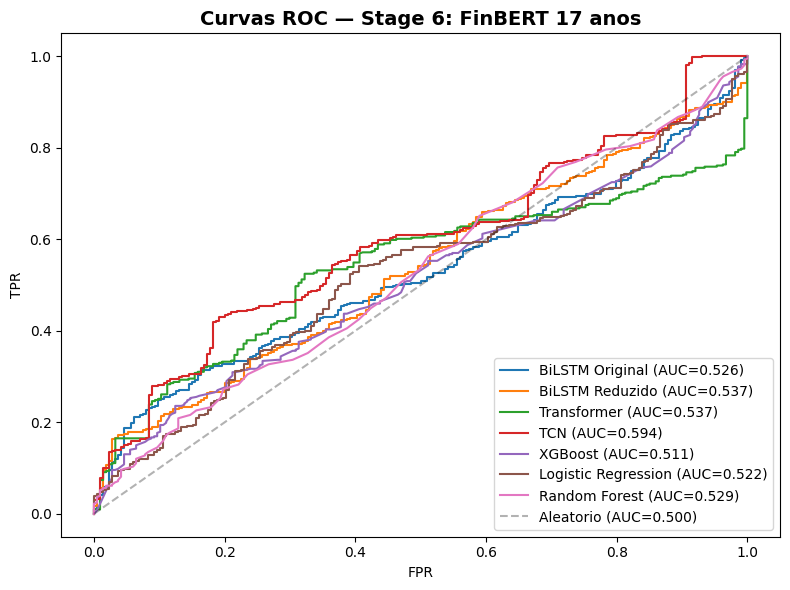

In [5]:
plot_roc_curves(results, title="Curvas ROC — Stage 6: FinBERT 17 anos",
                save_path="results/stage6_roc.png")

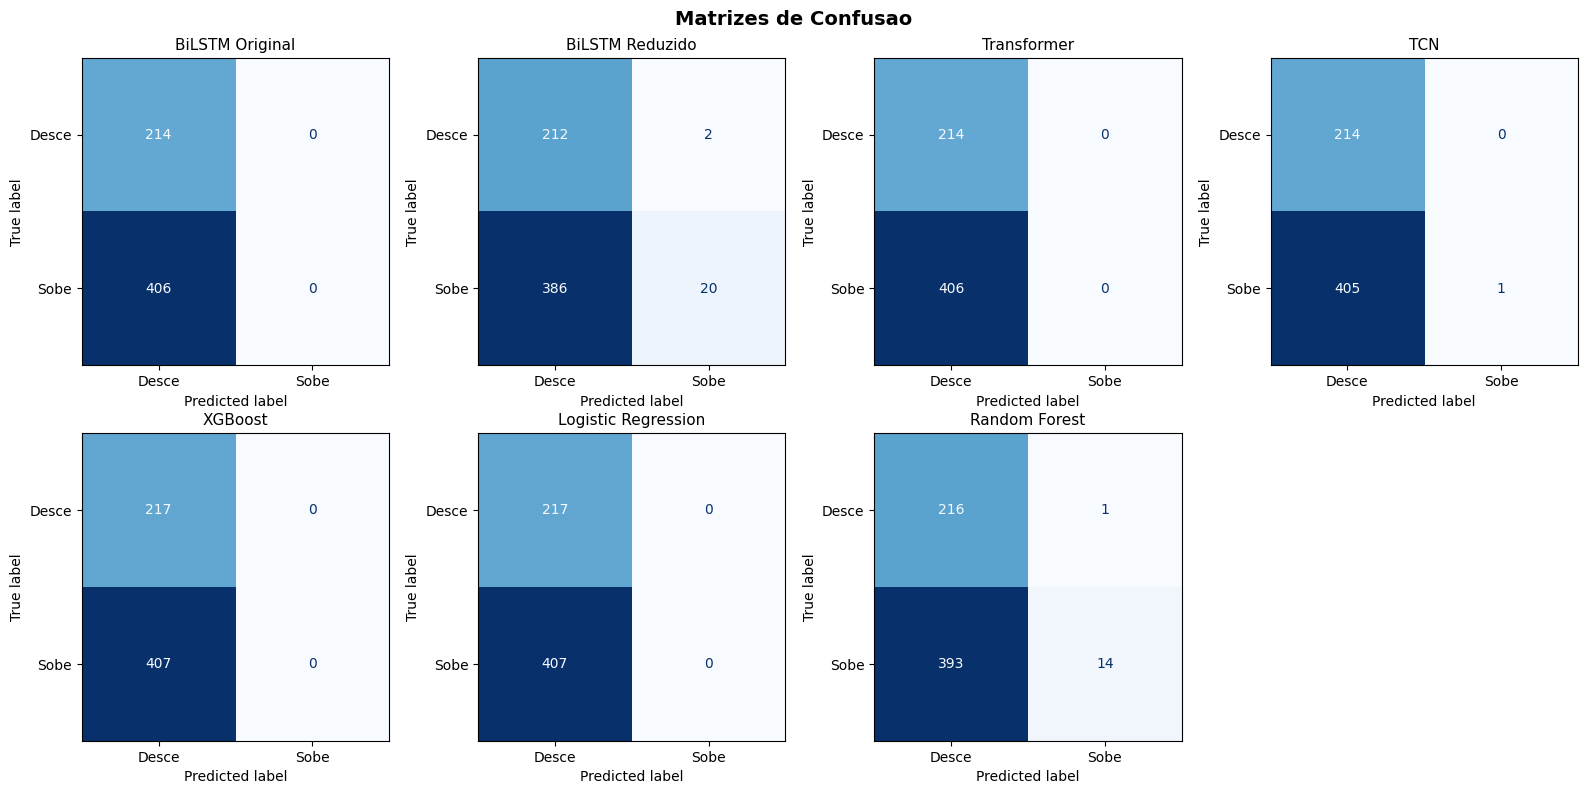

In [6]:
plot_confusion_matrices(
    {name: r["classification"] for name, r in results.items()},
    save_path="results/stage6_confusion.png",
)

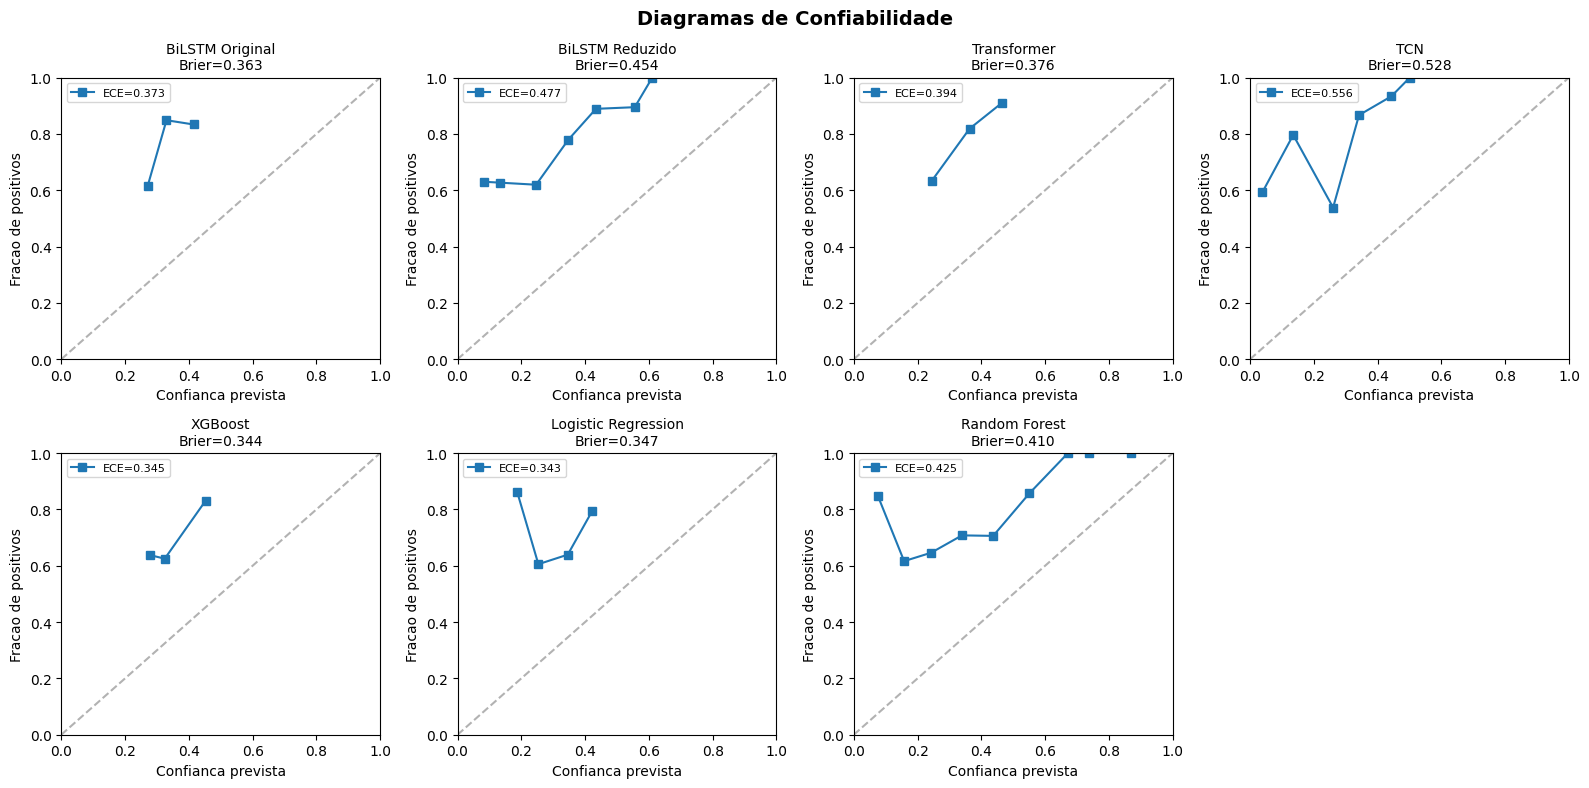

In [7]:
plot_calibration_diagrams(
    {name: r["calibration"] for name, r in results.items()},
    save_path="results/stage6_calibration.png",
)

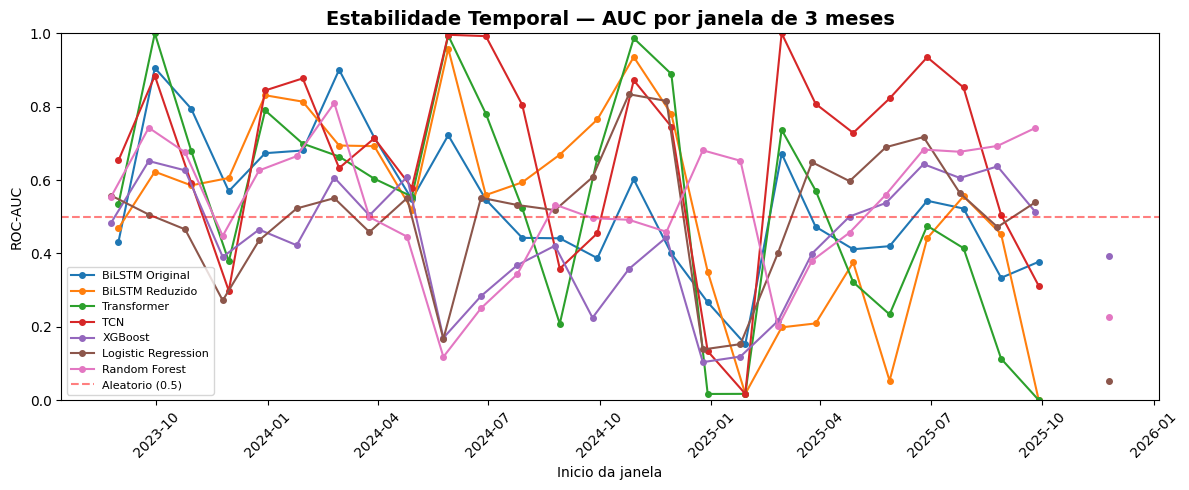

In [8]:
plot_temporal_stability(
    {name: r["temporal_stability"] for name, r in results.items()},
    save_path="results/stage6_temporal.png",
)

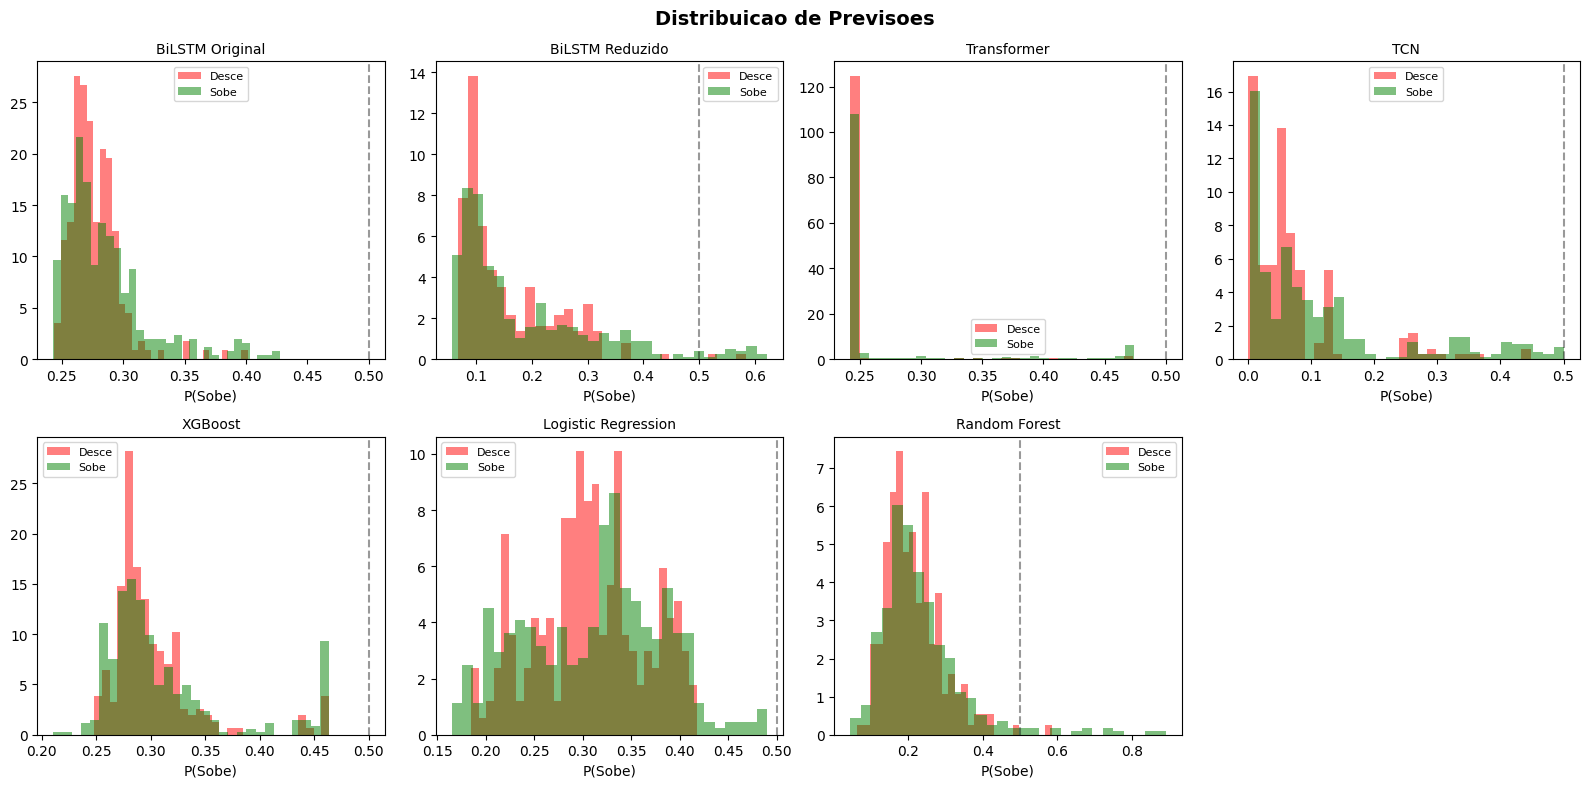

In [9]:
plot_prediction_distributions(
    {name: r["prediction_distribution"] for name, r in results.items()},
    save_path="results/stage6_distributions.png",
)

## Interpretabilidade (SHAP + Permutation Importance)

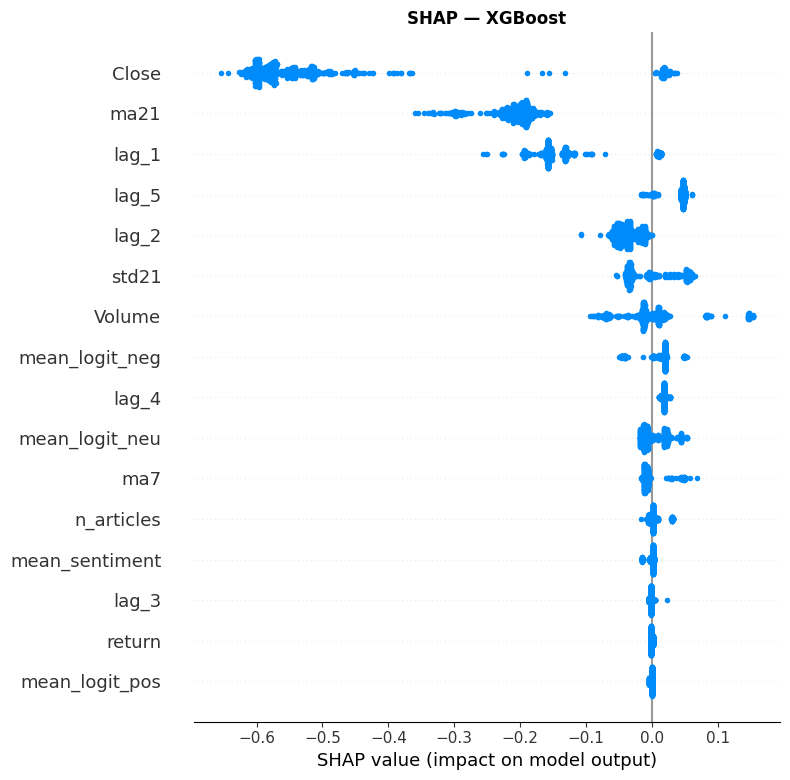

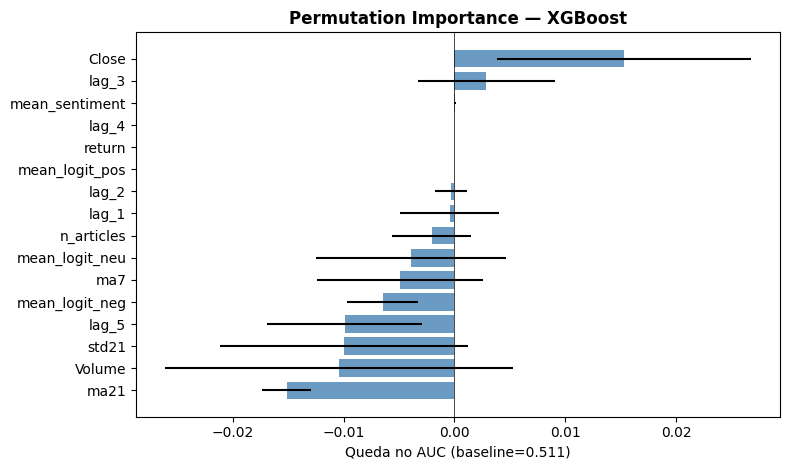

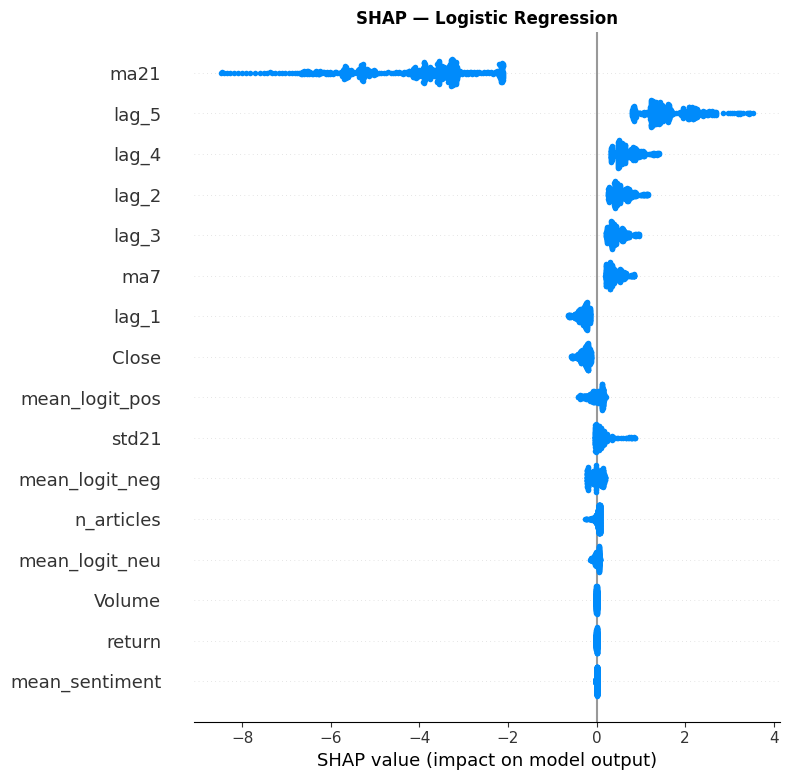

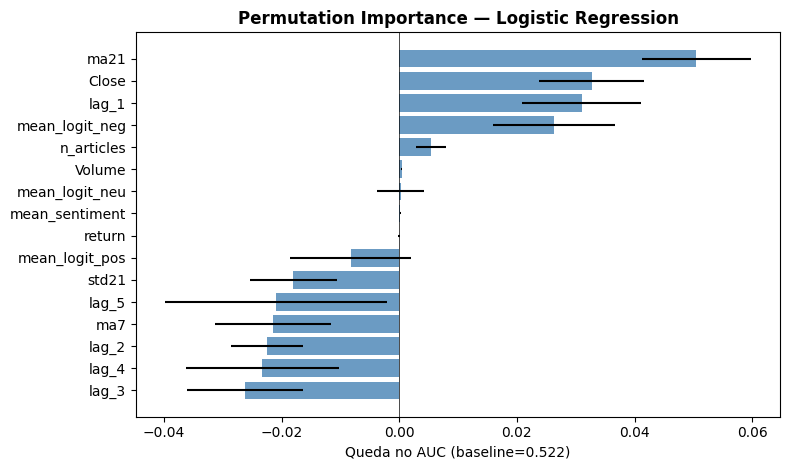

<Figure size 1000x480 with 0 Axes>

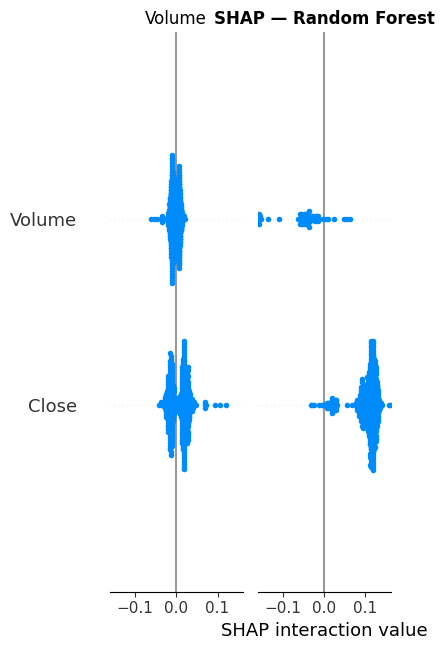

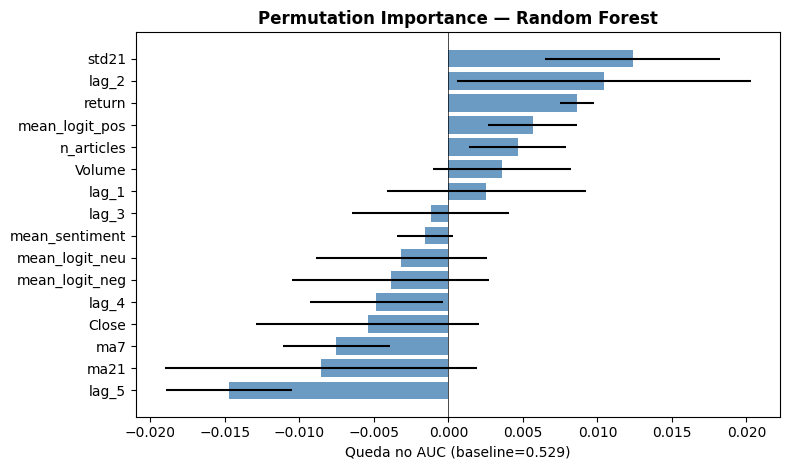

In [10]:
for name in ["XGBoost", "Logistic Regression", "Random Forest"]:
    r = results[name]
    if r["shap_values"] is not None:
        plot_shap_summary(
            r["shap_values"], data["feature_names"],
            title=f"SHAP — {name}",
            save_path=f"results/stage6_shap_{name.lower().replace(' ','_')}.png",
        )
    if r["permutation_importance"] is not None:
        plot_feature_importance(
            r["permutation_importance"],
            r["classification"]["roc_auc"],
            title=f"Permutation Importance — {name}",
            save_path=f"results/stage6_perm_{name.lower().replace(' ','_')}.png",
        )

## Curvas de aprendizado

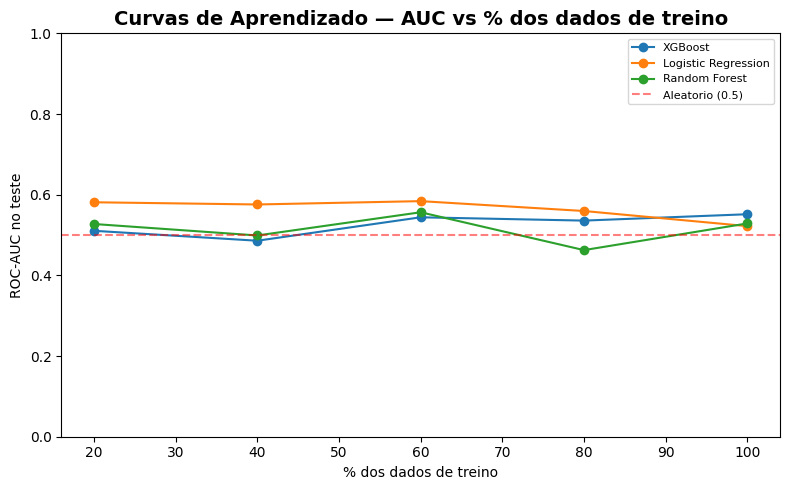

In [11]:
lc_results = {name: r["learning_curve"] for name, r in results.items()
               if r["learning_curve"] is not None}
if lc_results:
    plot_learning_curves(lc_results, save_path="results/stage6_learning_curves.png")

## Variacoes de hiperparametros

In [12]:
VARIATIONS = {
    "Transformer d=32": {"model_name": "transformer", "model_params": {"d_model": 32, "nhead": 2}},
    "Transformer d=128": {"model_name": "transformer", "model_params": {"d_model": 128, "nhead": 8}},
    "Transformer 4L": {"model_name": "transformer", "model_params": {"n_layers": 4}},
    "XGBoost depth=3": {"model_name": "xgboost", "model_params": {"max_depth": 3}},
    "XGBoost depth=6": {"model_name": "xgboost", "model_params": {"max_depth": 6}},
    "XGBoost 500 trees": {"model_name": "xgboost", "model_params": {"n_estimators": 500}},
    "BiLSTM drop=0.1": {"model_name": "bilstm_original", "model_params": {"dropout": 0.1}},
    "BiLSTM drop=0.5": {"model_name": "bilstm_original", "model_params": {"dropout": 0.5}},
    "BiLSTM h=256": {"model_name": "bilstm_original", "model_params": {"hidden_size": 256}},
    "TCN k=2": {"model_name": "tcn", "model_params": {"kernel_size": 2}},
    "TCN k=5": {"model_name": "tcn", "model_params": {"kernel_size": 5}},
    "TCN [32,32]": {"model_name": "tcn", "model_params": {"num_channels": [32, 32]}},
    "LR C=0.01": {"model_name": "logistic_regression", "model_params": {"C": 0.01}},
    "LR C=100": {"model_name": "logistic_regression", "model_params": {"C": 100}},
    "LR L1": {"model_name": "logistic_regression", "model_params": {"penalty": "l1", "solver": "saga"}},
    "RF depth=5": {"model_name": "random_forest", "model_params": {"max_depth": 5}},
    "RF depth=20": {"model_name": "random_forest", "model_params": {"max_depth": 20}},
    "RF 500 trees": {"model_name": "random_forest", "model_params": {"n_estimators": 500}},
}

var_results = {}
for display_name, config in VARIATIONS.items():
    print(f"Variacao: {display_name}")
    var_results[display_name] = train_and_evaluate(
        model_name=config["model_name"],
        data=data,
        model_params=config.get("model_params", {}),
        compute_shap=False,
        compute_learning_curve=False,
    )

19:06:17 [INFO] 
19:06:17 [INFO] Modelo: transformer
19:06:17 [INFO] Split — treino: 2887 | val: 618 | teste: 620
19:06:17 [INFO] ============================================================
19:06:17 [INFO] Class weights: sobe=0.792, desce=1.263 (balance: 55.8% sobe)


Variacao: Transformer d=32


19:06:17 [INFO] Epoch   1/50 | loss 0.7041 | val_loss 0.6823 | val_acc 46.8% | lr 1.00e-03
19:06:18 [INFO] Epoch   2/50 | loss 0.6908 | val_loss 0.6763 | val_acc 46.8% | lr 1.00e-03
19:06:19 [INFO] Epoch   3/50 | loss 0.6866 | val_loss 0.6731 | val_acc 46.8% | lr 1.00e-03
19:06:19 [INFO] Epoch   4/50 | loss 0.6865 | val_loss 0.6778 | val_acc 46.8% | lr 1.00e-03
19:06:20 [INFO] Epoch   5/50 | loss 0.6828 | val_loss 0.6639 | val_acc 48.9% | lr 1.00e-03
19:06:20 [INFO] Epoch   6/50 | loss 0.6833 | val_loss 0.6678 | val_acc 47.2% | lr 1.00e-03
19:06:21 [INFO] Epoch   7/50 | loss 0.6807 | val_loss 0.6648 | val_acc 50.0% | lr 1.00e-03
19:06:21 [INFO] Epoch   8/50 | loss 0.6788 | val_loss 0.6664 | val_acc 51.9% | lr 1.00e-03
19:06:22 [INFO] Epoch   9/50 | loss 0.6790 | val_loss 0.6676 | val_acc 58.3% | lr 1.00e-03
19:06:22 [INFO] Epoch  10/50 | loss 0.6796 | val_loss 0.6690 | val_acc 57.3% | lr 1.00e-03
19:06:23 [INFO] Epoch  11/50 | loss 0.6792 | val_loss 0.6769 | val_acc 53.7% | lr 5.00e-04

Variacao: Transformer d=128


19:06:25 [INFO] Epoch   1/50 | loss 0.7230 | val_loss 0.6869 | val_acc 46.8% | lr 1.00e-03
19:06:26 [INFO] Epoch   2/50 | loss 0.6882 | val_loss 0.6827 | val_acc 46.8% | lr 1.00e-03
19:06:27 [INFO] Epoch   3/50 | loss 0.6892 | val_loss 0.6915 | val_acc 46.8% | lr 1.00e-03
19:06:27 [INFO] Epoch   4/50 | loss 0.6889 | val_loss 0.6903 | val_acc 46.8% | lr 1.00e-03
19:06:28 [INFO] Epoch   5/50 | loss 0.6888 | val_loss 0.6861 | val_acc 46.8% | lr 1.00e-03
19:06:29 [INFO] Epoch   6/50 | loss 0.6911 | val_loss 0.6889 | val_acc 46.8% | lr 1.00e-03
19:06:30 [INFO] Epoch   7/50 | loss 0.6858 | val_loss 0.6736 | val_acc 46.8% | lr 1.00e-03
19:06:30 [INFO] Epoch   8/50 | loss 0.6849 | val_loss 0.6727 | val_acc 46.8% | lr 1.00e-03
19:06:31 [INFO] Epoch   9/50 | loss 0.6811 | val_loss 0.6795 | val_acc 46.8% | lr 1.00e-03
19:06:32 [INFO] Epoch  10/50 | loss 0.7006 | val_loss 0.6769 | val_acc 46.8% | lr 1.00e-03
19:06:32 [INFO] Epoch  11/50 | loss 0.6902 | val_loss 0.6734 | val_acc 46.8% | lr 1.00e-03

...

/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
1

Variacao: RF depth=20


19:08:33 [INFO] AUC: 0.5027 | Acc: 37.0% | F1: 0.0753 | ECE: 0.4188 | Brier: 0.4076
19:08:33 [INFO]               precision    recall  f1-score   support

       Desce       0.35      0.99      0.52       217
        Sobe       0.89      0.04      0.08       407

    accuracy                           0.37       624
   macro avg       0.62      0.52      0.30       624
weighted avg       0.70      0.37      0.23       624

19:08:37 [INFO] 
19:08:37 [INFO] Modelo: random_forest
19:08:37 [INFO] Split — treino: 2908 | val: 623 | teste: 624
19:08:37 [INFO] ============================================================


Variacao: RF 500 trees


19:08:38 [INFO] AUC: 0.5105 | Acc: 37.2% | F1: 0.0755 | ECE: 0.4265 | Brier: 0.4135
19:08:38 [INFO]               precision    recall  f1-score   support

       Desce       0.36      1.00      0.52       217
        Sobe       0.94      0.04      0.08       407

    accuracy                           0.37       624
   macro avg       0.65      0.52      0.30       624
weighted avg       0.74      0.37      0.23       624



In [13]:
var_rows = []
for name, r in var_results.items():
    var_rows.append({
        "Variacao": name,
        "ROC-AUC": f"{r['classification']['roc_auc']:.4f}",
        "Accuracy": f"{r['classification']['accuracy']:.1%}",
        "F1": f"{r['classification']['f1']:.4f}",
        "ECE": f"{r['calibration']['ece']:.4f}",
    })

df_var = pd.DataFrame(var_rows)
print("" + "="*60)
print("VARIACOES DE HIPERPARAMETROS")
print("="*60)
display(df_var)

VARIACOES DE HIPERPARAMETROS


,Variacao,ROC-AUC,Accuracy,F1,ECE
0,Transformer d=32,0.5695,34.5%,0.0000,0.3865
1,Transformer d=128,0.5441,34.5%,0.0000,0.4490
2,Transformer 4L,0.5641,34.5%,0.0000,0.3275
3,XGBoost depth=3,0.4885,34.8%,0.0000,0.3284
4,XGBoost depth=6,0.5061,34.8%,0.0000,0.2213
5,XGBoost 500 trees,0.5113,34.8%,0.0000,0.3445
6,BiLSTM drop=0.1,0.4955,34.7%,0.0049,0.4438
7,BiLSTM drop=0.5,0.5138,34.5%,0.0000,0.4323
8,BiLSTM h=256,0.4898,37.4%,0.0977,0.3634
9,TCN k=2,0.5837,34.7%,0.0049,0.5270


## Salvar resultados

In [14]:
all_results = {**results, **var_results}
save_results_json(all_results, "results/stage6_metrics.json")
print("Resultados salvos em results/stage6_metrics.json")

19:08:48 [INFO] Resultados salvos em results/stage6_metrics.json


Resultados salvos em results/stage6_metrics.json
